# Customer Analytics — Statistical Analysis

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from db_connection import get_engine
from queries import CUSTOMER_LTV, CUSTOMER_PURCHASE_DATES

sns.set_style('whitegrid')
engine = get_engine()

def gini(values):
    x = np.sort(np.asarray(values, dtype=float))
    n = len(x)
    cum = np.cumsum(x)
    return (2 * np.sum(np.arange(1, n + 1) * x) - (n + 1) * cum[-1]) / (n * cum[-1])

## 1. Gini Coefficient & Lorenz Curve

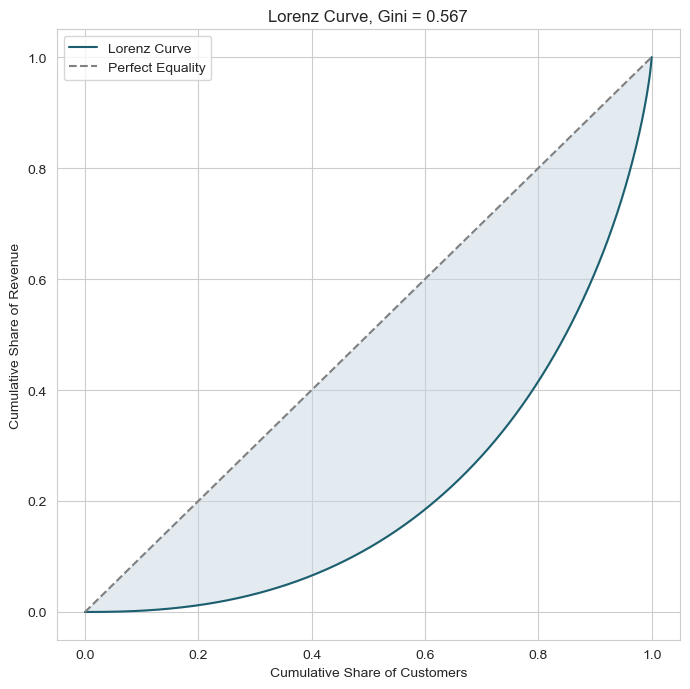

In [3]:
df_ltv = pd.read_sql(CUSTOMER_LTV, engine)

x_sorted = np.sort(df_ltv['total_ltv'].values)
n = len(x_sorted)
cum_revenue = np.cumsum(x_sorted) / x_sorted.sum()
cum_population = np.arange(1, n + 1) / n

lorenz_x = np.concatenate([[0], cum_population])
lorenz_y = np.concatenate([[0], cum_revenue])
gini_score = gini(x_sorted)

fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(lorenz_x, lorenz_y, color='#1b5e6e', label='Lorenz Curve')
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect Equality')
ax.fill_between(lorenz_x, lorenz_y, lorenz_x, color='#c8d8e4', alpha=0.5)
ax.set_xlabel('Cumulative Share of Customers')
ax.set_ylabel('Cumulative Share of Revenue')
ax.set_title(f'Lorenz Curve, Gini = {gini_score:.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('../../images/gini_lorenz_curve.png', dpi=150)
plt.show()

## 2. Distribution of Days Between Purchases

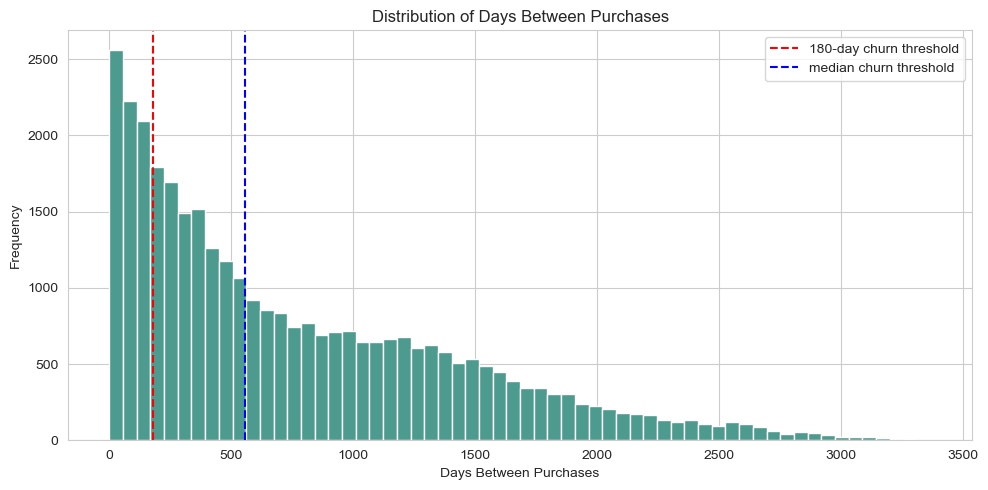

0.25     217.00
0.50     558.00
0.75    1193.25
0.90    1744.90
Name: gap_days, dtype: float64
21.5% of gaps are <= 180 days


In [ ]:
df_dates = pd.read_sql(CUSTOMER_PURCHASE_DATES, engine)
df_dates['orderdate'] = pd.to_datetime(df_dates['orderdate'])
df_dates = df_dates.sort_values(['customerkey', 'orderdate'])
df_dates['gap_days'] = df_dates.groupby('customerkey')['orderdate'].diff().dt.days

gaps = df_dates['gap_days'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(gaps, bins=60, color='#4d9a8f')
ax.axvline(180, color='red', linestyle='--', label='180-day churn threshold')
ax.axvline(558, color='blue', linestyle='--', label='median churn threshold')
ax.set_xlabel('Days Between Purchases')
ax.set_ylabel('Frequency')
ax.set_title('Distribution of Days Between Purchases')
ax.legend()
plt.tight_layout()
plt.savefig('../../images/purchase_gap_distribution.png', dpi=150)
plt.show()

print(gaps.quantile([0.25, 0.5, 0.75]))
print(f'{(gaps <= 180).mean() * 100:.1f}% of gaps are <= 180 days')